In [3]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

# Lab | Natural Language Processing
### SMS: SPAM or HAM

### Let's prepare the environment

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import string
import nltk
import scipy.sparse as sp
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.stem.snowball import SnowballStemmer

# Download required NLTK data
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /Users/sazao/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/sazao/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /Users/sazao/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/sazao/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

- Read Data for the Fraudulent Email Kaggle Challenge
- Reduce the training set to speead up development. 

In [10]:
## Read Data for the Fraudulent Email Kaggle Challenge
data = pd.read_csv("/Users/sazao/lab-natural-language-processing/data/kg_train.csv",encoding='latin-1')

# Reduce the training set to speed up development. 
# Modify for final system
data = data.head(1000)
print(data.shape)
data.fillna("",inplace=True)

(1000, 2)


### Let's divide the training and test set into two partitions

In [11]:
# Your code



data_train, data_val = train_test_split(
    data,
    test_size=0.2,
    random_state=42,
    stratify=data['label']
    )

print(f"Training set size: {data_train.shape}")
print(f"Validation set size: {data_val.shape}")
print(f"\nTraining label distribution:\n{data_train['label'].value_counts()}")

Training set size: (800, 2)
Validation set size: (200, 2)

Training label distribution:
label
0    446
1    354
Name: count, dtype: int64


## Data Preprocessing

In [12]:
import string
from nltk.corpus import stopwords
print(string.punctuation)
print(stopwords.words("english")[100:110])
from nltk.stem.snowball import SnowballStemmer
snowball = SnowballStemmer('english')

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~
['needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on']


## Now, we have to clean the html code removing words

- First we remove inline JavaScript/CSS
- Then we remove html comments. This has to be done before removing regular tags since comments can contain '>' characters
- Next we can remove the remaining tags

In [13]:
# Your code
def remove_html(text):
    text = re.sub(r'<(script|style)[^>]*>.*?</(script|style)>', '', text, flags=re.DOTALL | re.IGNORECASE)
    text = re.sub(r'<!--.*?-->', '', text, flags=re.DOTALL)
    text = re.sub(r'<[^>]+>', ' ', text)
    return text

sample_html = "<p>Hello <b>World</b>! <!-- comment --> <script>alert('x')</script>"
print(remove_html(sample_html))

 Hello  World !  


- Remove all the special characters
    
- Remove numbers
    
- Remove all single characters
 
- Remove single characters from the start

- Substitute multiple spaces with single space

- Remove prefixed 'b'

- Convert to Lowercase

In [14]:
# Your code
def clean_text(text):
    """
    Applies a series of regex-based cleaning steps to raw text.
    Returns a cleaned, lowercase string.
    """
    # Remove all special characters (keep only letters and spaces)
    text = re.sub(r'\W', ' ', text)

    # Remove standalone numbers (digits surrounded by spaces or at boundaries)
    text = re.sub(r'\b\d+\b', ' ', text)

    # Remove all single characters (e.g. leftover 'a', 'b', 'x')
    text = re.sub(r'\b[a-zA-Z]\b', ' ', text)

    # Remove single characters at the start of the string
    text = re.sub(r'^[a-zA-Z]\s', ' ', text)

    # Substitute multiple consecutive spaces with a single space
    text = re.sub(r' +', ' ', text)

    # Remove a prefixed 'b' that appears before a quoted string (Python byte strings artifact)
    # e.g. b'some text' -> 'some text'
    text = re.sub(r"^b\s*'", '', text)

    # Convert all text to lowercase
    text = text.lower()

    return text.strip()

# Test
print(clean_text("Hello W0rld!!! This is a TEST 123. b'example'"))

hello w0rld this is test example


## Now let's work on removing stopwords
Remove the stopwords.

In [15]:
# Your code
def remove_stopwords(text):
    """
    Removes English stop words from a string.
    Stop words are common words like 'the', 'is', 'and' that carry little meaning.
    """
    stop_words = set(stopwords.words('english'))

    # Split into words, filter out stop words, and rejoin
    filtered_words = [word for word in text.split() if word not in stop_words]

    return ' '.join(filtered_words)

# Test
print(remove_stopwords("this is a very important message about your account"))

important message account


## Tame Your Text with Lemmatization
Break sentences into words, then use lemmatization to reduce them to their base form (e.g., "running" becomes "run"). See how this creates cleaner data for analysis!

In [16]:
# Your code
def lemmatize_text(text):
    """
    Tokenizes the text and applies WordNet lemmatization to each word.
    Lemmatization reduces words to their dictionary base form:
    e.g. 'running' -> 'running' (noun default), 'better' -> 'good' (adj)
    Returns the lemmatized text as a single string.
    """
    lemmatizer = WordNetLemmatizer()

    # Split text into individual words and lemmatize each one
    lemmatized_words = [lemmatizer.lemmatize(word) for word in text.split()]

    return ' '.join(lemmatized_words)


def full_preprocessing_pipeline(text):
    """
    Runs all preprocessing steps in sequence:
    HTML removal -> text cleaning -> stopword removal -> lemmatization
    """
    text = remove_html(text)
    text = clean_text(text)
    text = remove_stopwords(text)
    text = lemmatize_text(text)
    return text


# Apply the full pipeline to both train and validation sets
# This creates a new column 'preprocessed_text' in each DataFrame
print("Preprocessing training data...")
data_train = data_train.copy()  # avoid SettingWithCopyWarning
data_val = data_val.copy()

data_train['preprocessed_text'] = data_train['text'].apply(full_preprocessing_pipeline)
data_val['preprocessed_text'] = data_val['text'].apply(full_preprocessing_pipeline)

print("Done!")
print("\nOriginal:    ", data_train['text'].iloc[0][:100])
print("Preprocessed:", data_train['preprocessed_text'].iloc[0][:100])

Preprocessing training data...
Done!

Original:     Dear=2C Good day hope fine=2Cdear am writting this mail with due respect and heartful of tears since
Preprocessed: dear 2c good day hope fine 2cdear writting mail due respect heartful tear since known met previously


## Bag Of Words
Let's get the 10 top words in ham and spam messages (**EXPLORATORY DATA ANALYSIS**)

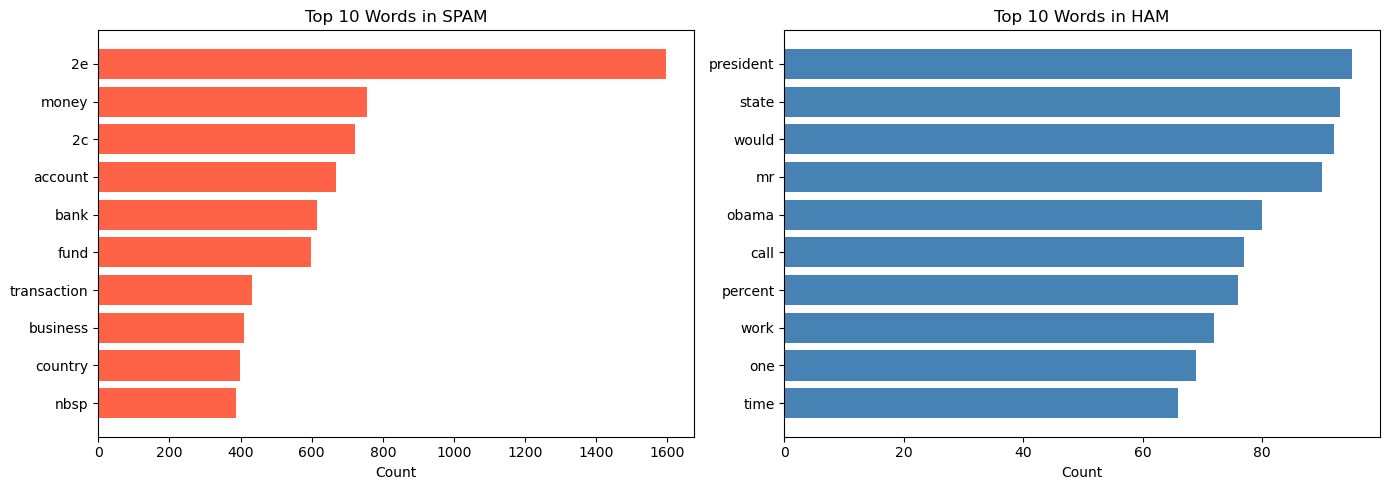


Top SPAM words:
       word  count
         2e   1595
      money    755
         2c    722
    account    669
       bank    614
       fund    597
transaction    433
   business    409
    country    397
       nbsp    387

Top HAM words:
     word  count
president     95
    state     93
    would     92
       mr     90
    obama     80
     call     77
  percent     76
     work     72
      one     69
     time     66


In [17]:
# Your code
def get_top_words(df, label_value, label_col='label', text_col='preprocessed_text', top_n=10):
    """
    Returns the top N most frequent words for a given class label.
    Uses CountVectorizer to count word frequencies.
    """
    # Filter rows for the given label (spam=1 or ham=0)
    subset = df[df[label_col] == label_value][text_col]

    # Use CountVectorizer to count word occurrences across all messages
    cv = CountVectorizer(max_features=1000)
    word_counts = cv.fit_transform(subset)

    # Sum counts across all documents and sort descending
    word_freq = pd.DataFrame({
        'word': cv.get_feature_names_out(),
        'count': word_counts.toarray().sum(axis=0)
    }).sort_values('count', ascending=False)

    return word_freq.head(top_n)


# Get top 10 words for spam (label=1) and ham (label=0)
top_spam = get_top_words(data_train, label_value=1)
top_ham  = get_top_words(data_train, label_value=0)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top_spam['word'], top_spam['count'], color='tomato')
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Words in SPAM')
axes[0].set_xlabel('Count')

axes[1].barh(top_ham['word'], top_ham['count'], color='steelblue')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Words in HAM')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

print("\nTop SPAM words:")
print(top_spam.to_string(index=False))
print("\nTop HAM words:")
print(top_ham.to_string(index=False))

## Extra features

In [18]:
# We add to the original dataframe two additional indicators (money symbols and suspicious words).
money_simbol_list = "|".join(["euro","dollar","pound","€",r"\$"])
suspicious_words = "|".join(["free","cheap","sex","money","account","bank","fund","transfer","transaction","win","deposit","password"])

data_train['money_mark'] = data_train['preprocessed_text'].str.contains(money_simbol_list)*1
data_train['suspicious_words'] = data_train['preprocessed_text'].str.contains(suspicious_words)*1
data_train['text_len'] = data_train['preprocessed_text'].apply(lambda x: len(x)) 

data_val['money_mark'] = data_val['preprocessed_text'].str.contains(money_simbol_list)*1
data_val['suspicious_words'] = data_val['preprocessed_text'].str.contains(suspicious_words)*1
data_val['text_len'] = data_val['preprocessed_text'].apply(lambda x: len(x)) 

data_train.head()

,text,label,preprocessed_text,money_mark,suspicious_words,text_len
442,Dear=2C Good day hope fine=2Cdear am writting ...,1,dear 2c good day hope fine 2cdear writting mai...,1,1,1048
962,FROM MR HENRY KABORETHE CHIEF AUDITOR INCHARGE...,1,mr henry kaborethe chief auditor inchargeforei...,0,1,2015
971,Will do.,0,,0,0,0
190,FROM THE DESK OF DR.ADAMU ISMALERAUDITING AND...,1,desk dr adamu ismalerauditing accounting manag...,1,1,386
551,"Dear Friend, My name is LOI C.ESTRADA,The wife...",1,dear friend name loi estrada wife mr josephest...,1,1,1491


## How would work the Bag of Words with Count Vectorizer concept?

In [19]:
# Your code
# Initialize CountVectorizer
# max_features=5000 keeps only the 5000 most frequent words (avoids overfitting on rare words)
# Each row = one message; each column = one word; value = word count in that message
bow_vectorizer = CountVectorizer(max_features=5000)

# fit on TRAINING data only, then transform both train and validation
# IMPORTANT: never fit on validation data to avoid data leakage
X_train_bow = bow_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_bow   = bow_vectorizer.transform(data_val['preprocessed_text'])

print("BoW Training matrix shape:  ", X_train_bow.shape)
print("BoW Validation matrix shape:", X_val_bow.shape)
print("\nSample vocabulary (first 10 words):", bow_vectorizer.get_feature_names_out()[:10])

BoW Training matrix shape:   (800, 5000)
BoW Validation matrix shape: (200, 5000)

Sample vocabulary (first 10 words): ['00hrs' '0a' '0d' '0h' '0px' '0z' '100k' '11th' '12m' '12refused']


## TF-IDF

- Load the vectorizer

- Vectorize all dataset

- print the shape of the vetorized dataset

In [20]:
# Your code
# Initialize TF-IDF Vectorizer
# TF-IDF downweights very common words across all messages (low IDF)
# and upweights words that are distinctive for specific messages (high TF)
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit on training data only, transform both sets
X_train_tfidf = tfidf_vectorizer.fit_transform(data_train['preprocessed_text'])
X_val_tfidf   = tfidf_vectorizer.transform(data_val['preprocessed_text'])

# Labels
y_train = data_train['label']
y_val   = data_val['label']

print("TF-IDF Training matrix shape:  ", X_train_tfidf.shape)
print("TF-IDF Validation matrix shape:", X_val_tfidf.shape)

TF-IDF Training matrix shape:   (800, 5000)
TF-IDF Validation matrix shape: (200, 5000)


## And the Train a Classifier?

In [22]:
# Train a Multinomial Naive Bayes classifier with TF-IDF features
# MultinomialNB works well with text data and word count/frequency features
# It assumes features follow a multinomial distribution (word counts per class)
nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_tfidf, y_train)

# Predict on validation set
y_pred = nb_classifier.predict(X_val_tfidf)

# Evaluate
print("=== Classifier Results (TF-IDF only) ===")
print(f"Accuracy: {accuracy_score(y_val, y_pred):.4f}")
print()
print(classification_report(y_val, y_pred, target_names=['HAM', 'SPAM']))

=== Classifier Results (TF-IDF only) ===
Accuracy: 0.9800

              precision    recall  f1-score   support

         HAM       1.00      0.96      0.98       112
        SPAM       0.96      1.00      0.98        88

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



### Extra Task - Implement a SPAM/HAM classifier

https://www.kaggle.com/t/b384e34013d54d238490103bc3c360ce

The classifier can not be changed!!! It must be the MultinimialNB with default parameters!

Your task is to **find the most relevant features**.

For example, you can test the following options and check which of them performs better:
- Using "Bag of Words" only
- Using "TF-IDF" only
- Bag of Words + extra flags (money_mark, suspicious_words, text_len)
- TF-IDF + extra flags


You can work with teams of two persons (recommended).

In [23]:
# Your code
# Helper function to evaluate any feature combination with MultinomialNB
def evaluate_features(X_train, X_val, y_train, y_val, label):
    """
    Trains a MultinomialNB (default params) on X_train and evaluates on X_val.
    Prints accuracy and classification report.
    The classifier is fixed as MultinomialNB — only features change.
    """
    clf = MultinomialNB()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    print(f"\n{'='*50}")
    print(f"  {label}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"{'='*50}")
    print(classification_report(y_val, y_pred, target_names=['HAM', 'SPAM']))
    return acc


# ---- Extra flags as a sparse matrix (so we can stack with BoW/TF-IDF) ----
# We use scipy.sparse to keep everything sparse and compatible with MultinomialNB
extra_train = sp.csr_matrix(data_train[['money_mark', 'suspicious_words', 'text_len']].values)
extra_val   = sp.csr_matrix(data_val[['money_mark', 'suspicious_words', 'text_len']].values)


# ---- Option 1: Bag of Words only ----
acc1 = evaluate_features(X_train_bow, X_val_bow, y_train, y_val,
                          "Option 1: Bag of Words only")

# ---- Option 2: TF-IDF only ----
acc2 = evaluate_features(X_train_tfidf, X_val_tfidf, y_train, y_val,
                          "Option 2: TF-IDF only")

# ---- Option 3: BoW + extra flags ----
# hstack combines the BoW matrix and extra flags column-wise
X_train_bow_extra = sp.hstack([X_train_bow, extra_train])
X_val_bow_extra   = sp.hstack([X_val_bow,   extra_val])
acc3 = evaluate_features(X_train_bow_extra, X_val_bow_extra, y_train, y_val,
                          "Option 3: Bag of Words + extra flags")

# ---- Option 4: TF-IDF + extra flags ----
X_train_tfidf_extra = sp.hstack([X_train_tfidf, extra_train])
X_val_tfidf_extra   = sp.hstack([X_val_tfidf,   extra_val])
acc4 = evaluate_features(X_train_tfidf_extra, X_val_tfidf_extra, y_train, y_val,
                          "Option 4: TF-IDF + extra flags")


# ---- Summary ----
results = pd.DataFrame({
    'Features': [
        'BoW only',
        'TF-IDF only',
        'BoW + extra flags',
        'TF-IDF + extra flags'
    ],
    'Accuracy': [acc1, acc2, acc3, acc4]
}).sort_values('Accuracy', ascending=False)

print("\n" + "="*40)
print("   FEATURE COMPARISON SUMMARY")
print("="*40)
print(results.to_string(index=False))
print("\nBest feature set:", results.iloc[0]['Features'])


  Option 1: Bag of Words only
  Accuracy: 0.9700
              precision    recall  f1-score   support

         HAM       0.99      0.96      0.97       112
        SPAM       0.95      0.99      0.97        88

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200


  Option 2: TF-IDF only
  Accuracy: 0.9800
              precision    recall  f1-score   support

         HAM       1.00      0.96      0.98       112
        SPAM       0.96      1.00      0.98        88

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200


  Option 3: Bag of Words + extra flags
  Accuracy: 0.9600
              precision    recall  f1-score   support

         HAM       0.99      0.94      0.96       112
        SPAM       0.93      0.99      0.96        88

    accuracy                 